<a href="https://colab.research.google.com/github/rachmadnanda/MachineLearning2026/blob/main/DBScanManhattan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import time
import tracemalloc
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Library siap.")

Library siap.


In [2]:
df = pd.read_csv('dataset_properti.csv')
print("Shape awal:", df.shape)
df.head()

Shape awal: (1530, 8)


,id_properti,lokasi,luas_m2,jumlah_kamar,jumlah_kamar_mandi,usia_bangunan,harga,kategori_harga
0,PROP0655,Tangerang,30.0,3,3.0,33.0,203754275,Murah
1,PROP0077,Bekasi,122.0,5,4.0,19.0,1058031695,Murah
2,PROP0317,Bekasi,142.8,1,1.0,9.0,1335792780,Mahal
3,PROP1348,Bekasi,152.6,4,3.0,6.0,1613770786,Mahal
4,PROP0572,Depok,61.2,1,1.0,9.0,522156222,Murah


In [3]:
# ============================================
# PREPROCESSING UNIVERSAL (identik dengan Euclidean)
# ============================================

# 1. Drop ID
df = df.drop(columns=['id_properti'])

# 2. Drop duplikat
before = len(df)
df = df.drop_duplicates()
print(f"[1] Hapus duplikat       : {before} -> {len(df)}")

# 3. Bersihkan satuan "m2"
df['luas_m2'] = df['luas_m2'].astype(str).str.replace(' m2', '', regex=False)
df['luas_m2'] = pd.to_numeric(df['luas_m2'], errors='coerce')

# 4. Standarisasi lokasi
df['lokasi'] = df['lokasi'].str.strip().str.title()
df['lokasi'] = df['lokasi'].replace({'Jak. Utara': 'Jakarta Utara',
                                      'Jak. Selatan': 'Jakarta Selatan'})

# 5. Isi missing values
numeric_cols = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
                'usia_bangunan', 'harga']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
print(f"[2] Missing values diisi  : {df[numeric_cols].isnull().sum().sum()} tersisa")

# 6. Hapus outlier ekstrem
before = len(df)
df = df[df['harga'] < 100_000_000_000]
df = df[df['luas_m2'] < 1000]
print(f"[3] Hapus outlier ekstrem : {before} -> {len(df)}")

# 7. Reset index
df = df.reset_index(drop=True)

# 8. Feature selection & scaling
FEATURES = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi',
            'usia_bangunan', 'harga']
X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"[4] Data siap clustering  : {X_scaled.shape}")
print(f"[5] Fitur                 : {FEATURES}")

[1] Hapus duplikat       : 1530 -> 1500
[2] Missing values diisi  : 0 tersisa
[3] Hapus outlier ekstrem : 1500 -> 1498
[4] Data siap clustering  : (1498, 5)
[5] Fitur                 : ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']


min_samples = 10


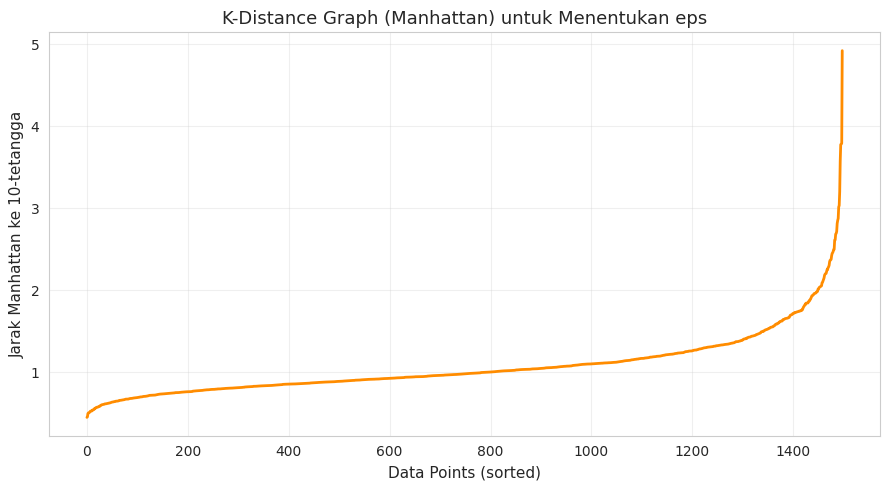


Kandidat eps berdasarkan persentil:
  Persentil 85: 1.3431
  Persentil 90: 1.5194
  Persentil 92: 1.6229
  Persentil 95: 1.8130
  Persentil 97: 2.0361


In [4]:
# min_samples tetap sama
MIN_SAMPLES = 2 * len(FEATURES)
print(f"min_samples = {MIN_SAMPLES}")

# Hitung jarak ke k-tetangga (Manhattan)
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES, metric='manhattan')
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

# Plot k-distance graph
plt.figure(figsize=(9, 5))
plt.plot(distances, color='darkorange', linewidth=2)
plt.xlabel('Data Points (sorted)', fontsize=11)
plt.ylabel(f'Jarak Manhattan ke {MIN_SAMPLES}-tetangga', fontsize=11)
plt.title('K-Distance Graph (Manhattan) untuk Menentukan eps', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Kandidat eps
print("\nKandidat eps berdasarkan persentil:")
for p in [85, 90, 92, 95, 97]:
    print(f"  Persentil {p}: {np.percentile(distances, p):.4f}")

In [5]:
# ============================================
# PARAMETER (sesuaikan EPS_VALUE dari Cell 4)
# ============================================
EPS_VALUE = 1.0
MIN_SAMPLES = 2 * len(FEATURES)

# Tracking
tracemalloc.start()
start_time = time.time()

# Training dengan metric Manhattan
dbscan = DBSCAN(eps=EPS_VALUE, min_samples=MIN_SAMPLES, metric='manhattan')
labels = dbscan.fit_predict(X_scaled)

exec_time = time.time() - start_time
_, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Simpan
df['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("="*55)
print("HASIL DBSCAN (MANHATTAN)")
print("="*55)
print(f"eps                  : {EPS_VALUE}")
print(f"min_samples          : {MIN_SAMPLES}")
print(f"Jumlah cluster       : {n_clusters}")
print(f"Jumlah noise/outlier : {n_noise} ({n_noise/len(df)*100:.2f}%)")
print(f"Waktu eksekusi       : {exec_time:.4f} detik")
print(f"Peak memory          : {peak/1024:.2f} KB")
print("\nDistribusi cluster:")
print(df['cluster'].value_counts().sort_index())

HASIL DBSCAN (MANHATTAN)
eps                  : 1.0
min_samples          : 10
Jumlah cluster       : 1
Jumlah noise/outlier : 314 (20.96%)
Waktu eksekusi       : 0.1176 detik
Peak memory          : 422.21 KB

Distribusi cluster:
cluster
-1     314
 0    1184
Name: count, dtype: int64


In [6]:
cluster_only = df[df['cluster'] != -1]
print("Rata-rata fitur per cluster (tanpa noise):")
print(cluster_only.groupby('cluster')[FEATURES].mean().round(2))

Rata-rata fitur per cluster (tanpa noise):
         luas_m2  jumlah_kamar  jumlah_kamar_mandi  usia_bangunan  \
cluster                                                             
0          98.07          2.81                2.39          19.95   

                harga  
cluster                
0        1.038970e+09  


In [7]:
print("\nDistribusi lokasi per cluster:")
print(pd.crosstab(df['cluster'], df['lokasi']))

print("\nDistribusi kategori harga per cluster:")
print(pd.crosstab(df['cluster'], df['kategori_harga']))


Distribusi lokasi per cluster:
lokasi   Bekasi  Bogor  Depok  Jakarta Selatan  Jakarta Utara  Tangerang
cluster                                                                 
-1           34     27     31              120             62         40
 0          233    241    216              105            181        208

Distribusi kategori harga per cluster:
kategori_harga  Mahal  Murah
cluster                     
-1                292     22
 0                457    727


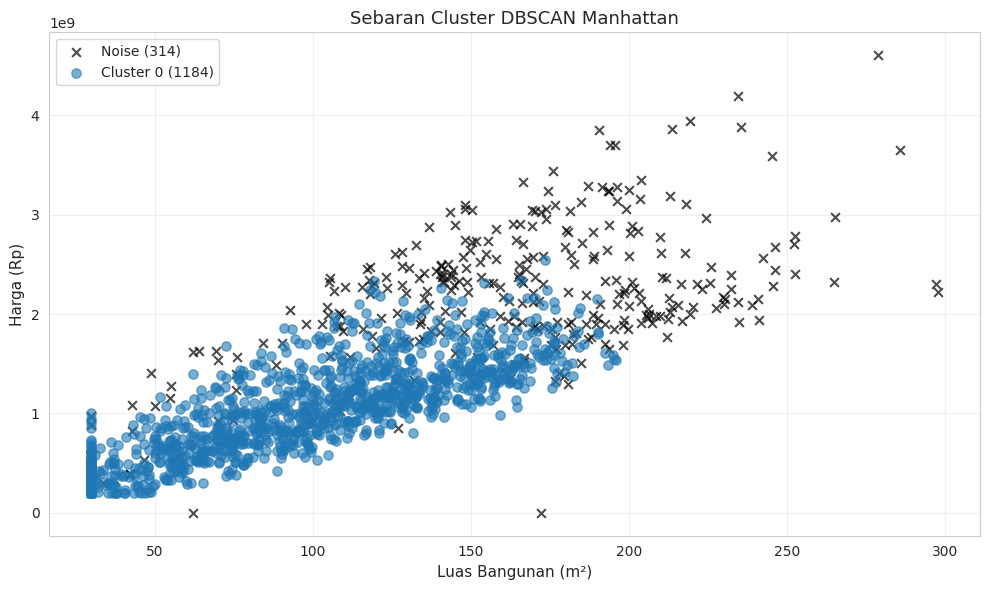

In [8]:
plt.figure(figsize=(10, 6))

for label in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == label]
    if label == -1:
        plt.scatter(subset['luas_m2'], subset['harga'],
                    c='black', marker='x', s=40, alpha=0.7,
                    label=f'Noise ({len(subset)})')
    else:
        plt.scatter(subset['luas_m2'], subset['harga'],
                    s=45, alpha=0.6, label=f'Cluster {label} ({len(subset)})')

plt.xlabel('Luas Bangunan (m²)', fontsize=11)
plt.ylabel('Harga (Rp)', fontsize=11)
plt.title('Sebaran Cluster DBSCAN Manhattan', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

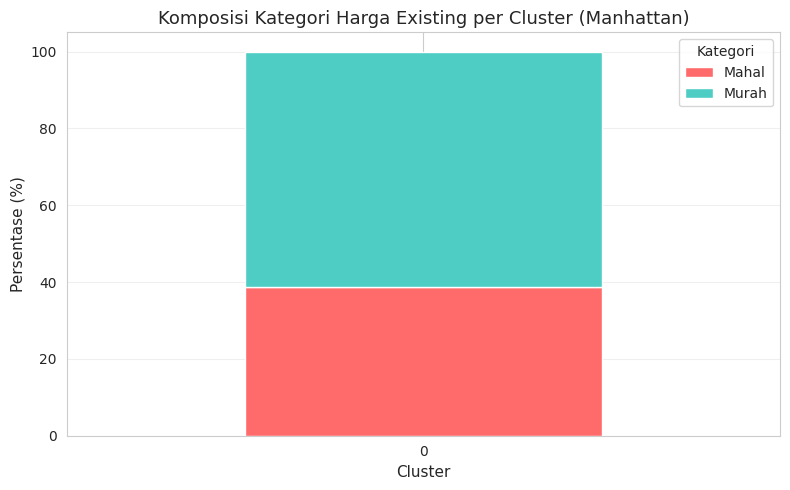


Persentase kategori harga per cluster (%):
kategori_harga  Mahal  Murah
cluster                     
0                38.6   61.4


In [9]:
comp = pd.crosstab(cluster_only['cluster'],
                   cluster_only['kategori_harga'],
                   normalize='index') * 100

comp.plot(kind='bar', stacked=True, figsize=(8, 5),
          color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
plt.xlabel('Cluster', fontsize=11)
plt.ylabel('Persentase (%)', fontsize=11)
plt.title('Komposisi Kategori Harga Existing per Cluster (Manhattan)', fontsize=13)
plt.legend(title='Kategori', loc='upper right')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nPersentase kategori harga per cluster (%):")
print(comp.round(2))

In [10]:
mask = df['cluster'] != -1

if len(set(df.loc[mask, 'cluster'])) > 1:
    sil_score = silhouette_score(X_scaled[mask],
                                  df.loc[mask, 'cluster'],
                                  metric='manhattan')
    print(f"Silhouette Score (Manhattan): {sil_score:.4f}")
else:
    sil_score = None
    print("Silhouette tidak dapat dihitung (cluster < 2)")

Silhouette tidak dapat dihitung (cluster < 2)


In [11]:
hasil_dbscan_manhattan = {
    'Metode'              : 'DBSCAN',
    'Distance Metric'     : 'Manhattan',
    'Jumlah Cluster'      : n_clusters,
    'Jumlah Noise'        : n_noise,
    'Waktu Eksekusi (s)'  : round(exec_time, 4),
    'Peak Memory (KB)'    : round(peak / 1024, 2),
    'Silhouette Score'    : round(sil_score, 4) if sil_score else None,
    'Parameter'           : f'eps={EPS_VALUE}, min_samples={MIN_SAMPLES}'
}

tabel = pd.DataFrame([hasil_dbscan_manhattan])
print("="*60)
print("RINGKASAN METRIK — DBSCAN MANHATTAN")
print("="*60)
tabel.T

RINGKASAN METRIK — DBSCAN MANHATTAN


,0
Metode,DBSCAN
Distance Metric,Manhattan
Jumlah Cluster,1
Jumlah Noise,314
Waktu Eksekusi (s),0.1176
Peak Memory (KB),422.21
Silhouette Score,None
Parameter,"eps=1.0, min_samples=10"
